In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [3]:
df = pd.read_csv("../data/smartcart_customers.csv")


# Data preprocessing

# Handle missing values

In [4]:
df["Income"] = df["Income"].fillna(df["Income"].median())

# Feature engineering

In [5]:
# Age

df["Age"] = 2026-df["Year_Birth"]

In [6]:
# Customer Tenure days 

df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], dayfirst= True)

reference_date = df["Dt_Customer"].max()

df["Customer_Tenure_Days"] = (reference_date - df["Dt_Customer"]).dt.days

In [7]:
#Spending 

df["Total_Spending"] = df["MntWines"] + df["MntFruits"] + df["MntMeatProducts"] + df["MntFishProducts"] + df["MntSweetProducts"] + df["MntGoldProds"]

In [8]:
# children

df["Total_Children"] = df["Kidhome"] + df["Teenhome"]


In [9]:
# Education
df["Education"].value_counts()
df["Education"] = df["Education"].replace(
    {"Basic": "Undergraduate", "2n Cycle": "Undergraduate", 
     "Master": "Postgraduate", "PhD": "Postgraduate",
     "Graduation": "Graduate"
    }
)

In [10]:
# marital status
df["Living_With"] = df["Marital_Status"].replace({
    "Married": "Partner", "Together": "Partner",
    "Single": "Alone", "Divorced": "Alone",
    "Widow": "Alone", "Absurd": "Alone", "YOLO": "Alone"
})

 Drop Columns

In [11]:
# drop unnecessary columns
cols = ["Year_Birth", "Marital_Status", "Kidhome", "Teenhome", "Dt_Customer", "ID", "MntWines", "MntGoldProds", "MntFruits", "MntMeatProducts", "MntFishProducts", "MntSweetProducts",   ]
df_cleaned = df.drop(columns = cols)
df_cleaned.shape

(2240, 15)

In [12]:
df_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Living_With
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Partner
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,Partner
4,Postgraduate,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,Partner


# Outlier

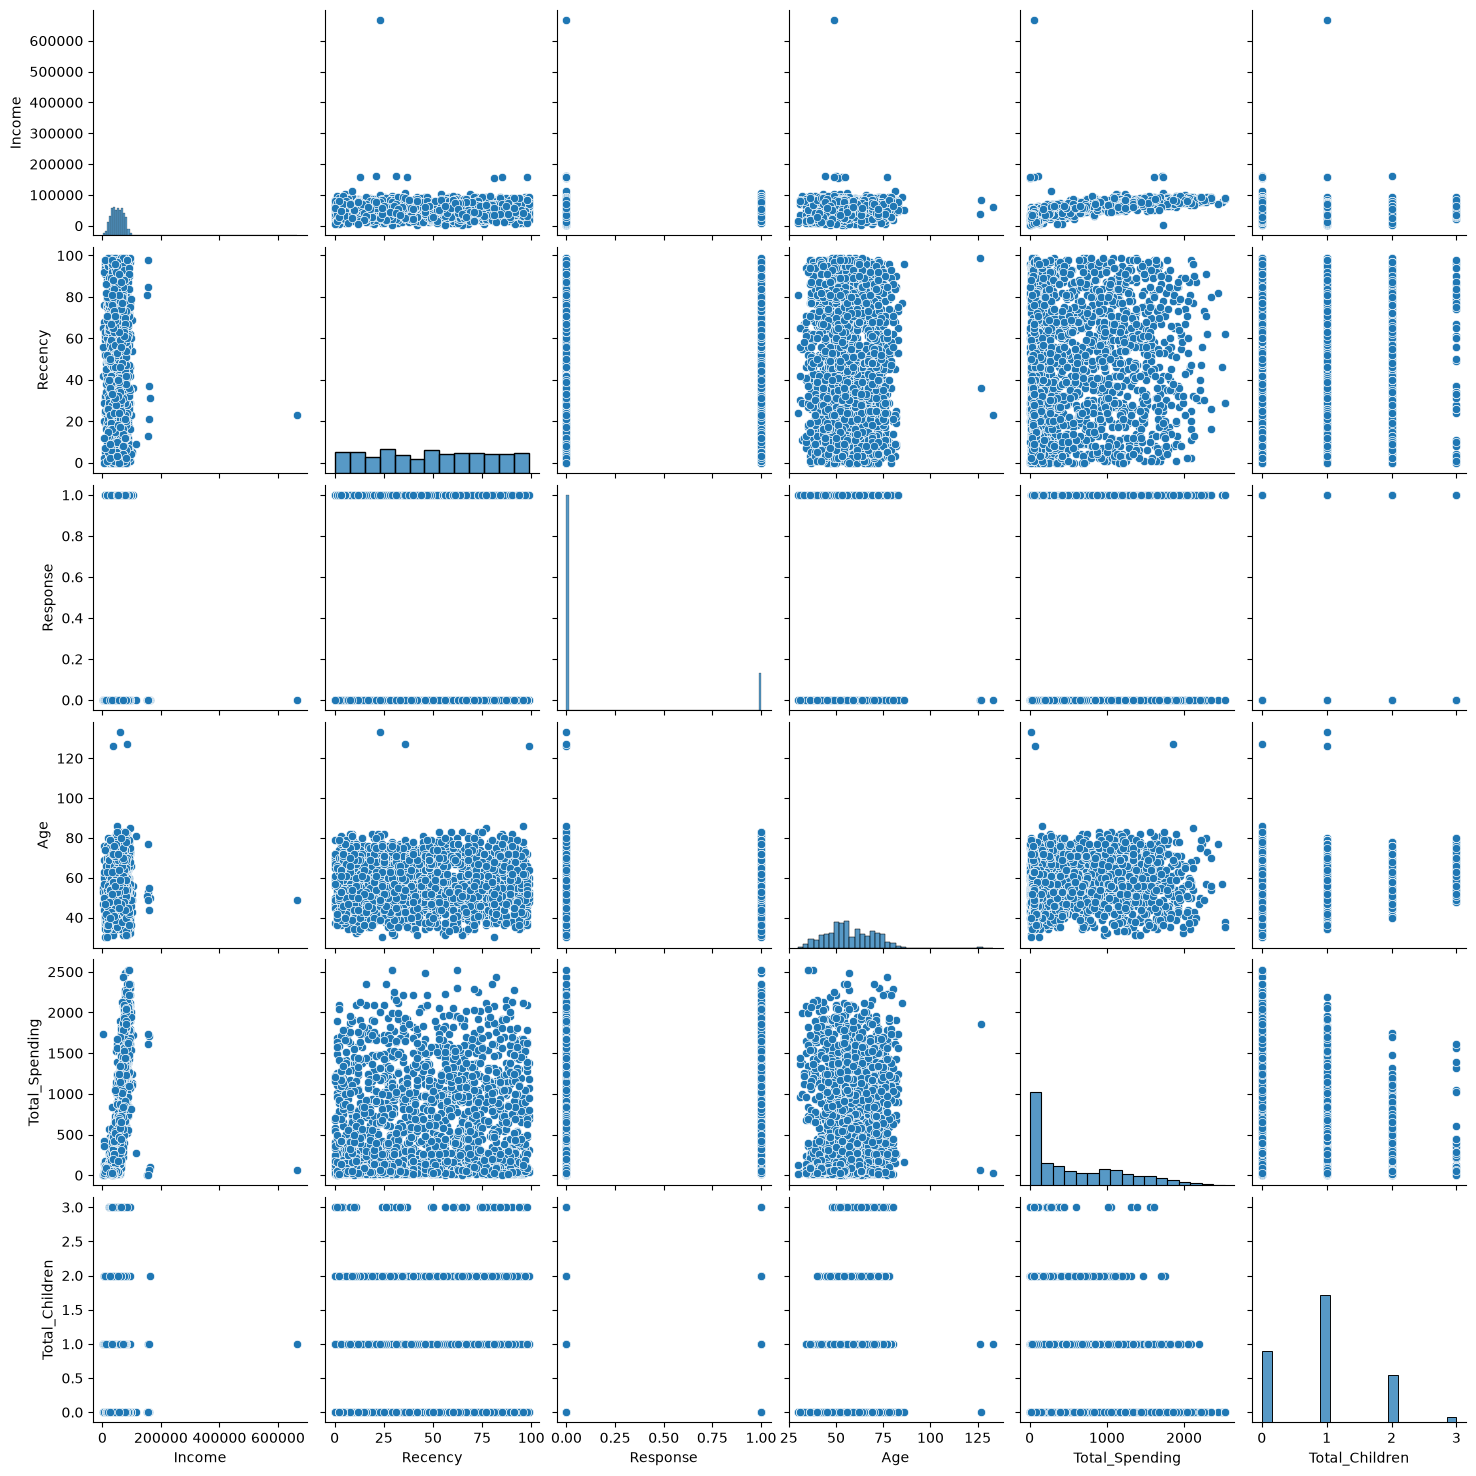

In [13]:
cols = ["Income", "Recency", "Response", "Age", "Total_Spending", "Total_Children"]

# relative plots of some features -> pair plots
sns.pairplot(df_cleaned[cols])

1. outlier in Income 60,000 +
2. outlier in Age 100 + 

In [14]:
# Remove Outliers

print("data size with outliers: ", len(df_cleaned))

df_cleaned = df_cleaned[df_cleaned["Age"]<90]
df_cleaned = df_cleaned[df_cleaned["Income"]<600_000]


print("data size without outliers: ", len(df_cleaned))

data size with outliers:  2240
data size without outliers:  2236


# Heatmap

In [15]:
corr = df_cleaned.corr(numeric_only = True)


<Axes: >

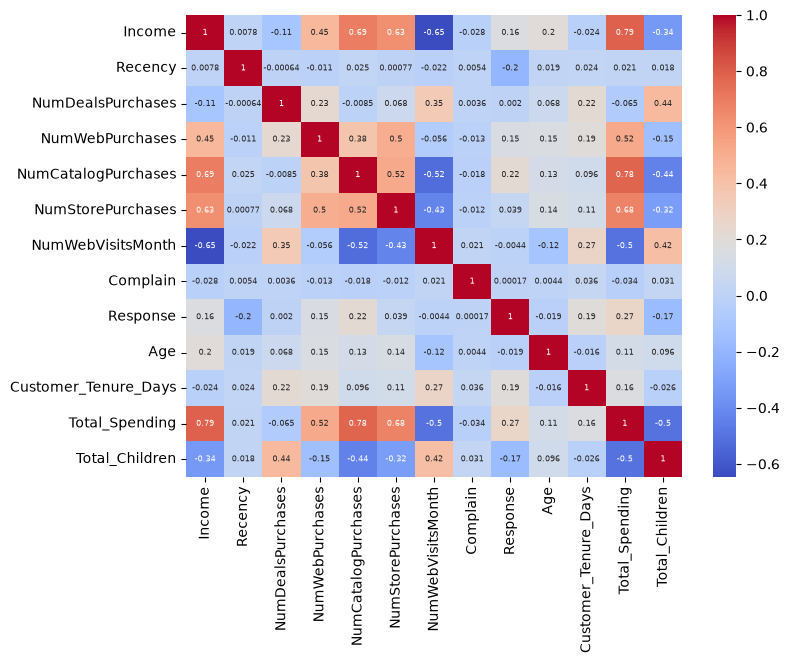

In [16]:
plt.figure(figsize = (8,6))

sns.heatmap(
    corr,
    cmap="coolwarm",
    annot=True,
    annot_kws={"size": 6}
    
    
)

In [ ]:
 # Income and total_spending correlation is high 
 # Income and numcatalogpurchases is hugh 
 # income and store purchases is high 
 # income and webvisit is low 
 # total spending and numcatalogpurchases is hugh
 # total spending and number of store purchaes is high

# Clustering on shoping behaviour

In [17]:
behavior_cols = [
    "Income", "Total_Spending", "Recency",
    "NumDealsPurchases", "NumWebPurchases",
    "NumCatalogPurchases", "NumStorePurchases", "NumWebVisitsMonth"
]
X = df_cleaned[behavior_cols]

# Scaling

In [18]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()

X_scaled = sc.fit_transform(X)

# Choosing the number of clusters 

# Elbow method

In [19]:
from sklearn.cluster import KMeans
from kneed import KneeLocator

wcss = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

knee = KneeLocator(k_range, wcss, curve="convex", direction="decreasing")
optimal_k = knee.elbow
print("Elbow at k =", optimal_k)

Elbow at k = 3


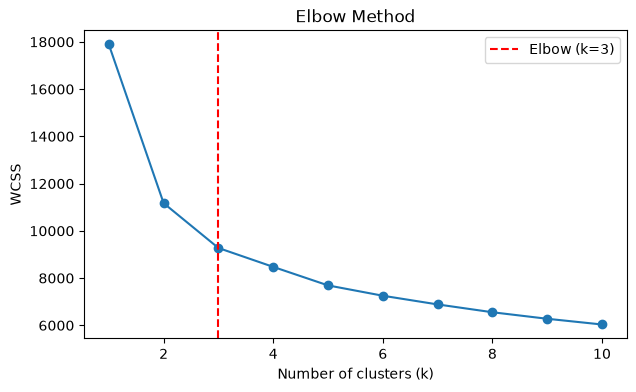

In [20]:
plt.figure(figsize=(7, 4))
plt.plot(k_range, wcss, marker="o")
plt.axvline(optimal_k, linestyle="--", color="red", label=f"Elbow (k={optimal_k})")
plt.title("Elbow Method")
plt.xlabel("Number of clusters (k)")
plt.ylabel("WCSS")
plt.legend()
plt.show()

#The elbow is at k = 3. After this point, adding more clusters only lowers WCSS a little.

# Silhoutte score

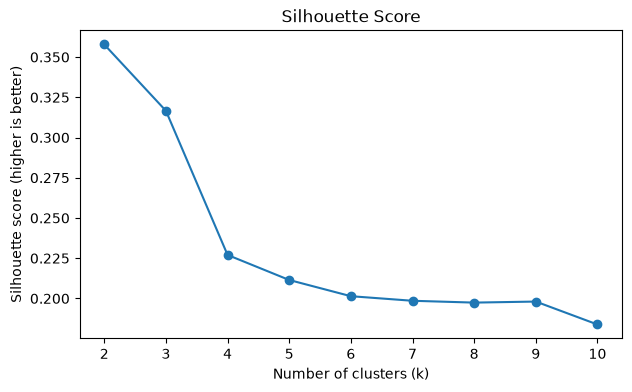

In [21]:
from sklearn.metrics import silhouette_score

sil_scores = []
sil_range = range(2, 11)

for k in sil_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, labels))

plt.figure(figsize=(7, 4))
plt.plot(sil_range, sil_scores, marker="o")
plt.title("Silhouette Score")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette score (higher is better)")
plt.show()

Choosing between k = 3 and k = 4

* The elbow method suggests k = 3.
* The silhouette score is highest at k = 2, but two groups are too simple to be useful for marketing.
* The silhouette score stays reasonable for k = 3 and k = 4, then drops sharply at k = 5.

Since both 3 and 4 are reasonable, I will fit both and compare the clusters. I will choose the one that gives clearer and more useful customer groups for the business.

# CLUSTERING 


For k = 3

In [22]:
kmeans3 = KMeans(n_clusters=3, random_state=42, n_init=10)
df_cleaned["cluster_3"] = kmeans3.fit_predict(X_scaled)

In [23]:
df_cleaned.groupby("cluster_3")[behavior_cols].mean().round(1)

,Income,Total_Spending,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth
cluster_3,,,,,,,,
0,34617.4,95.1,49.0,1.9,2.0,0.6,3.2,6.4
1,54771.6,697.3,48.3,4.4,6.8,2.7,7.3,6.5
2,75283.6,1287.3,49.9,1.4,5.0,5.7,8.4,2.9


For k = 4

In [24]:
kmeans4 = KMeans(n_clusters=4, random_state=42, n_init=10)
df_cleaned["cluster_4"] = kmeans4.fit_predict(X_scaled)

In [25]:
df_cleaned.groupby("cluster_4")[behavior_cols].mean().round(1)


,Income,Total_Spending,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth
cluster_4,,,,,,,,
0,56095.8,739.4,47.9,4.4,7.0,2.9,7.6,6.4
1,33964.5,100.3,24.4,2.0,2.1,0.5,3.2,6.6
2,36430.7,115.3,75.7,2.0,2.2,0.7,3.4,6.2
3,75524.6,1298.1,49.7,1.3,5.0,5.8,8.4,2.8


Decision: k = 4

With k = 3, the low-spending customers are all in one group. With k = 4, that group splits by Recency: one group bought recently (about 24 days ago), and the other has not bought in about 76 days. These two groups need different marketing (keep engaged vs win back), so k = 4 gives more useful segments.

In [26]:
segment_names = {
    0: "Deal-Seeking Regulars",
    1: "Active Budget Shoppers",
    2: "Inactive / At-Risk",
    3: "Premium Big Spenders"
}
df_cleaned["Segment"] = df_cleaned["cluster_4"].map(segment_names)
df_cleaned["Segment"].value_counts()

Segment
Premium Big Spenders      676
Active Budget Shoppers    550
Inactive / At-Risk        520
Deal-Seeking Regulars     490
Name: count, dtype: int64

# Who is in each segment?

In [27]:
# age, children and campaign response
df_cleaned.groupby("Segment")[["Age", "Total_Children", "Response"]].mean().round(2)

,Age,Total_Children,Response
Segment,,,
Active Budget Shoppers,54.31,1.20,0.14
Deal-Seeking Regulars,59.68,1.21,0.16
Inactive / At-Risk,55.80,1.24,0.03
Premium Big Spenders,58.50,0.33,0.24


In [28]:
# living situation 
pd.crosstab(df_cleaned["Segment"], df_cleaned["Living_With"], normalize="index").round(2)

Living_With,Alone,Partner
Segment,,
Active Budget Shoppers,0.35,0.65
Deal-Seeking Regulars,0.36,0.64
Inactive / At-Risk,0.36,0.64
Premium Big Spenders,0.36,0.64


In [29]:
# Education
pd.crosstab(df_cleaned["Segment"], df_cleaned["Education"], normalize="index").round(2)

Education,Graduate,Postgraduate,Undergraduate
Segment,,,
Active Budget Shoppers,0.48,0.37,0.16
Deal-Seeking Regulars,0.48,0.44,0.08
Inactive / At-Risk,0.51,0.34,0.15
Premium Big Spenders,0.54,0.39,0.08


Key findings

* Premium Big Spenders have the fewest children (0.33 on average) and the highest campaign response (24%). They are the best target for new campaigns.
* Inactive / At-Risk customers respond very rarely (3%). Normal campaigns do not work for them, so they need a special win-back offer.
* Deal-Seeking Regulars respond fairly well (16%) and buy the most on deals, so discount campaigns fit them.
* Living situation is almost the same in every segment. This confirms that it does not explain shopping behavior, so leaving it out of the clustering was the right choice.
* Age and education differ only slightly between segments.

# Charts 

In [30]:
segment_order = [
    "Premium Big Spenders",
    "Deal-Seeking Regulars",
    "Active Budget Shoppers",
    "Inactive / At-Risk"
]
segment_colors = {
    "Premium Big Spenders": "#2E86AB",
    "Deal-Seeking Regulars": "#F6AE2D",
    "Active Budget Shoppers": "#55A630",
    "Inactive / At-Risk": "#D1495B"
}

# Chart 1: number of customers per segment

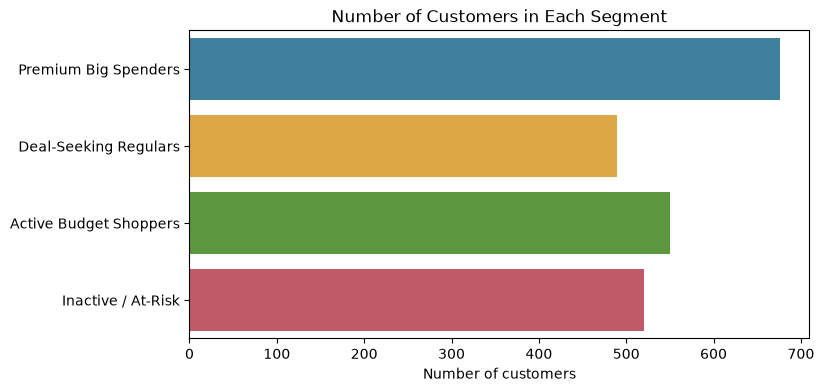

In [31]:
plt.figure(figsize=(8, 4))
sns.countplot(
    data=df_cleaned,
    y="Segment",
    order=segment_order,
    hue="Segment",
    palette=segment_colors
)
plt.title("Number of Customers in Each Segment")
plt.xlabel("Number of customers")
plt.ylabel("")
plt.show()

The segments are fairly balanced. Premium Big Spenders is the largest group (about 30% of customers), and almost 1 in 4 customers is Inactive / At-Risk, which is a big group to win back.

# Chart 2: Income vs Total Spending

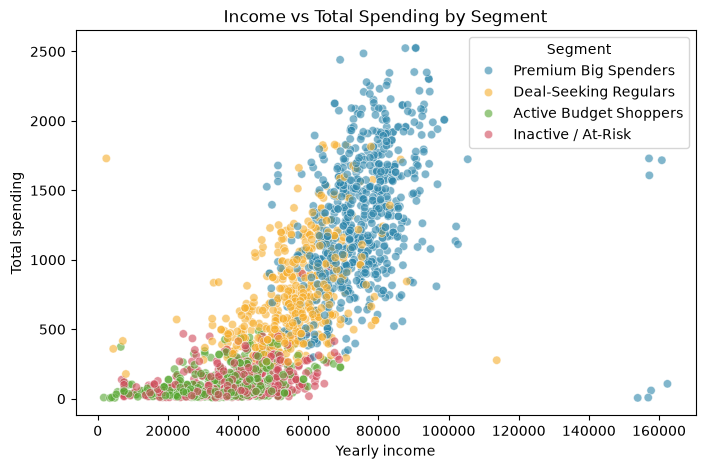

In [32]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df_cleaned,
    x="Income",
    y="Total_Spending",
    hue="Segment",
    hue_order=segment_order,
    palette=segment_colors,
    alpha=0.6
)
plt.title("Income vs Total Spending by Segment")
plt.xlabel("Yearly income")
plt.ylabel("Total spending")
plt.legend(title="Segment")
plt.show()

Premium Big Spenders form a clear group with high income and high spending. Active Budget Shoppers and Inactive / At-Risk customers overlap here because they have similar income and spending. The difference between them is Recency (how recently they bought), which this chart does not show.

Data quality note: 7 customers have an income of about 155–162k but very unusual purchase behavior (most bought almost nothing). These are likely data errors. Because they are only 0.3% of the data, I kept them, but in a real project I would check them with the data owner.

# Chart 3: Campaign response rate by segment

In [33]:
response_rate = (
    df_cleaned.groupby("Segment")["Response"].mean() * 100
).reindex(segment_order)

response_rate.round(1)

Segment
Premium Big Spenders      24.4
Deal-Seeking Regulars     15.5
Active Budget Shoppers    13.8
Inactive / At-Risk         3.3
Name: Response, dtype: float64

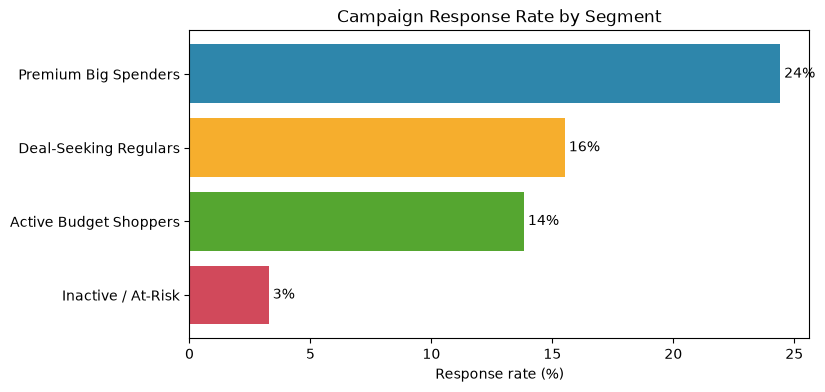

In [34]:
plt.figure(figsize=(8, 4))
bars = plt.barh(
    response_rate.index,
    response_rate.values,
    color=[segment_colors[s] for s in response_rate.index]
)
plt.bar_label(bars, fmt="%.0f%%", padding=3)
plt.title("Campaign Response Rate by Segment")
plt.xlabel("Response rate (%)")
plt.gca().invert_yaxis()
plt.show()

Premium Big Spenders respond the most to campaigns (24%), which is about 8 times more than Inactive / At-Risk customers (3%). Sending the same campaign to everyone wastes money on segments that rarely respond. The store should focus regular campaigns on Premium and Deal-Seeking customers, and design a different win-back offer for Inactive customers.

## Customer Segments

| Segment | Customers | Key traits | Campaign response | What the store should do |
|---|---|---|---|---|
| **Premium Big Spenders** | 676 (30%) | Highest income (~75k), highest spending (~1,300), few children, buy a lot from catalog and store | **24%** (highest) | VIP program, premium products, early access to new items |
| **Deal-Seeking Regulars** | 490 (22%) | Middle income (~56k), medium spending (~740), use the most deals, buy a lot online | 16% | Discount codes, online sales, bundle deals |
| **Active Budget Shoppers** | 550 (25%) | Lower income (~34k), low spending (~100), bought recently (~24 days ago) | 14% | Low-cost bundles and loyalty points to slowly raise spending |
| **Inactive / At-Risk** | 520 (23%) | Lower income (~36k), low spending (~115), have not bought in ~76 days | **3%** (lowest) | Special "we miss you" offer; stop sending regular campaigns that don't work |

## Key Takeaways

1. **Not all customers should get the same campaign.** Premium customers respond 8 times more than Inactive customers.
2. **Almost 1 in 4 customers is at risk of leaving.** A targeted win-back offer could bring some of them back.
3. **Recency matters.** Two segments look the same in income and spending, but one is active and one is leaving.
4. **Demographics like living situation don't explain shopping behavior**, so the segments are based on how customers shop.

## Limitations

- The data is from one store and one point in time.
- 7 customers have unusual income and purchase values that are likely data errors.
- Campaign response is based on only one past campaign.

In [35]:
# Save the model for the app 

import joblib

# Save the scaler and the KMeans model
joblib.dump(sc, "../models/scaler.pkl")
joblib.dump(kmeans4, "../models/kmeans.pkl")

# Save extra info the app needs
joblib.dump(behavior_cols, "../models/behavior_cols.pkl")
joblib.dump(segment_names, "../models/segment_names.pkl")

# Save the data with segments (for charts in the app)
df_cleaned.to_csv("../data/customers_with_segments.csv", index=False)

print("Saved!")

Saved!
